# Predictive Analysis of Precipitation Trends in Toronto

This project applies the K-Nearest Neighbors regressor on precipitation data tracked across all of Toronto's wards to predict the precipitation levels in millimetres for the month of August. Precipitation data for Toronto is taken from the ["Rain Gauge Locations and Precipitation"](https://open.toronto.ca/dataset/rain-gauge-locations-and-precipitation/) dataset found on the municipal Open Data website. Toronto's wards are used to simplify and aggregate regions for rain tracking purposes.

To begin the project, the current precipitation data and the geospatial data on Toronto's wards need to be loaded. This requires the use of both Pandas and GeoPandas, as GeoPandas best represents and allows for the manipulation of geospatial data.

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

data = pd.read_csv("precipitation-data-2026.csv")
data["date"] = pd.to_datetime(data["date"])

toronto = gpd.read_file("wards.geojson")

I also wanted to process the main directional boundaries - north, south, east and west - of any given ward. To do this, I wrote a script to process the Wards GeoJSON file, review all coordinates listed, and return the major coordinate boundaries for every given ward in a dictionary. Previously, I used Claude to get the coordinates, but I preferred to redo this part as the processing of coordinates seemed really simple once I figured out how JSON is helpful for acccessing and manipulating data in Python.

In [81]:
from process_wards import wards

for k, v in wards.items():
    print(k, v)

Humber River-Black Creek [43.7129901010899, 43.7815790749568, -79.5852117269988, -79.4881735629245]
York Centre [43.717755170299, 43.792407466692, -79.513221023395, -79.4114492180327]
Willowdale [43.7492940526654, 43.8032701311798, -79.4466762521224, -79.38715209799]
University-Rosedale [43.6493340834881, 43.6950870228904, -79.4293964137968, -79.3597108499133]
Beaches-East York [43.6541630526509, 43.719785826787, -79.3330914324973, -79.2790326884178]
Scarborough Southwest [43.6716713902779, 43.7431820122067, -79.3026450183565, -79.2127612905359]
Scarborough-Rouge Park [43.7518781562957, 43.8554571861712, -79.2322978138953, -79.1154514950547]
Scarborough North [43.7772824387948, 43.8420905838785, -79.2973325288169, -79.215721815678]
Scarborough-Guildwood [43.7280935596794, 43.7965219057717, -79.2549798538438, -79.1792029490005]
Scarborough Centre [43.7247131323866, 43.781222537134, -79.3197941465542, -79.2286728302396]
Scarborough-Agincourt [43.7683633049312, 43.8259504741618, -79.34131

Once the major directional boundaries of each ward were identified, the directional boundaries were joined with the main dataset containing the precipitation data in order to map the precipitation in millimetres to each ward. However, there can exist many rain gauges per each ward. As a workaround, I decided to take the rain gauge which reported the most amount of precipitation within one ward. I wrapped the logic of precipitation in a function to retrieve the precipitation levels for each month, as the logic will be similar to all other months.

In [82]:
def process_to_density(dataset):
    dataset = dataset.groupby('name').agg(
        total_rainfall=('rainfall', 'sum'),
        latitude = ('latitude', 'mean'),
        longitude = ('longitude', 'mean')
    )

    dataset = dataset.reset_index(names="name")
    dataset["ward"] = "N/A"

    for (idx, row) in enumerate(dataset.loc[:,["name", "latitude", "longitude"]].itertuples()):
        lat = row.latitude
        long = row.longitude
        for k, v in wards.items():
            if v[0] <= lat and lat <= v[1] and v[2] <= long and long <= v[3]:
                dataset.at[idx, "ward"] = k
                break

    dataset = dataset.groupby('ward').agg(
        rainfall = ('total_rainfall', 'max')
    )

    return dataset

In [83]:
january = data.query("date < '2026-02-01'")
january = process_to_density(january)

february = data.query("date >= '2026-02-01' and date < '2026-03-01'")
february = process_to_density(february)

march = data.query("date >= '2026-03-01' and date < '2026-04-01'")
march = process_to_density(march)

april = data.query("date >= '2026-04-01' and date < '2026-05-01'")
april = process_to_density(april)

may = data.query("date >= '2026-05-01' and date < '2026-06-01'")
may = process_to_density(may)

june = data.query("date >= '2026-06-01' and date < '2026-07-01'")
june = process_to_density(june)

july = data.query("date >= '2026-07-01' and date < '2026-08-01'")
july = process_to_density(july)

Given that all precipitation levels for each month before August are now mapped to each ward, the precipitation data can be plotted as densities within Toronto's wards. As a guide, the deeper the blue colour is per each ward, the more that ward has experienced rain.

Text(24.722222222222214, 0.5, 'Longitude')

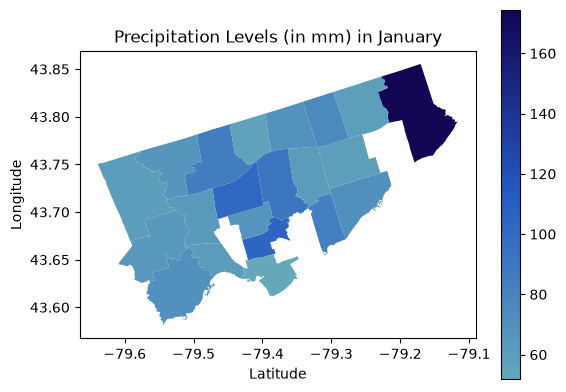

In [84]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

january_to = pd.merge(toronto, january, how="inner", left_on="AREA_NAME", right_index=True)
january_axis = january_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in January")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

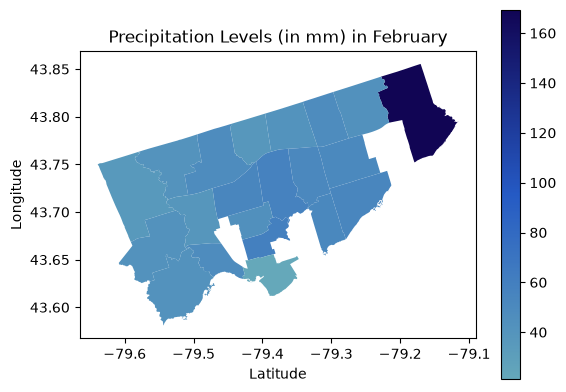

In [85]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

february_to = pd.merge(toronto, february, how="inner", left_on="AREA_NAME", right_index=True)
february_axis = february_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in February")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

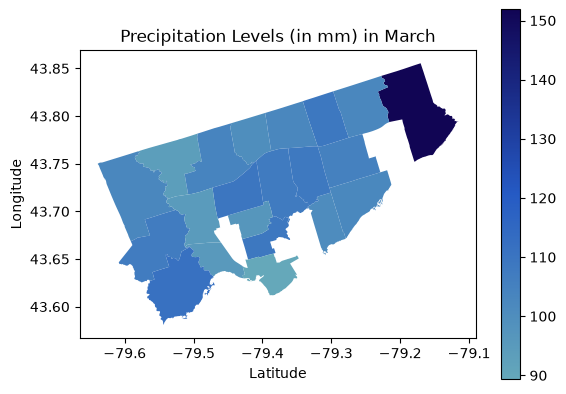

In [86]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

march_to = pd.merge(toronto, march, how="inner", left_on="AREA_NAME", right_index=True)
march_axis = march_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in March")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

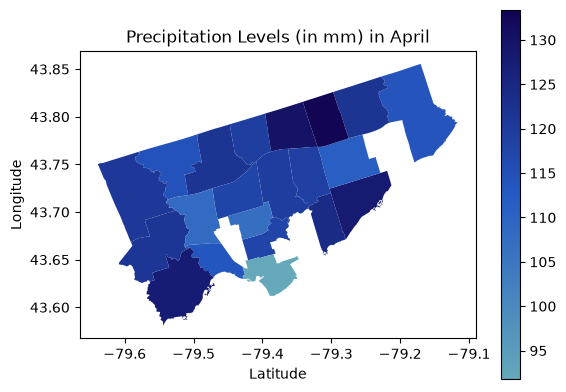

In [87]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

april_to = pd.merge(toronto, april, how="inner", left_on="AREA_NAME", right_index=True)
april_axis = april_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in April")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

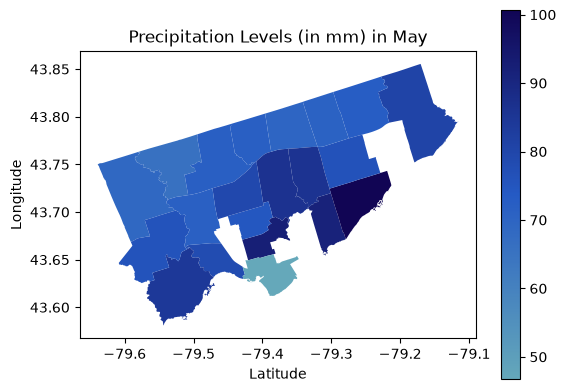

In [88]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

may_to = pd.merge(toronto, may, how="inner", left_on="AREA_NAME", right_index=True)
may_axis = may_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in May")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

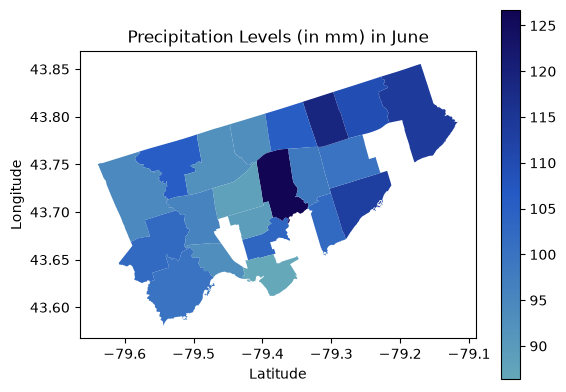

In [89]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

june_to = pd.merge(toronto, june, how="inner", left_on="AREA_NAME", right_index=True)
june_axis = june_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in June")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

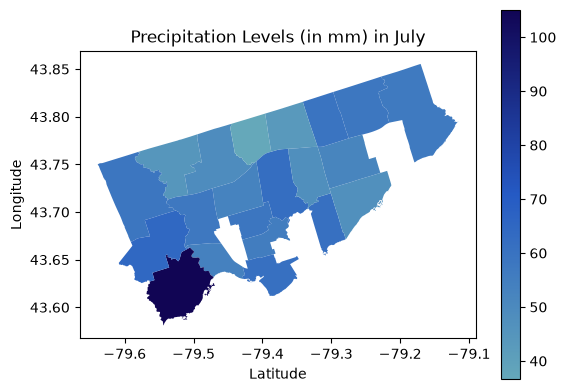

In [90]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

july_to = pd.merge(toronto, july, how="inner", left_on="AREA_NAME", right_index=True)
july_axis = july_to.plot("rainfall", legend=True, cmap=rain_colormap)
plt.title("Precipitation Levels (in mm) in July")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

In [91]:
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


monthly_data_knn = pd.concat([january.rename(columns={"rainfall": "January"})
                          ,february.rename(columns={"rainfall": "February"})
                          ,march.rename(columns={"rainfall": "March"})
                          ,april.rename(columns={"rainfall": "April"})
                          ,may.rename(columns={"rainfall": "May"})
                          ,june.rename(columns={"rainfall": "June"})
                          ,july.rename(columns={"rainfall": "July"})
                          ], axis=1)

monthly_data_dtr = pd.concat([january.rename(columns={"rainfall": "January"})
                          ,february.rename(columns={"rainfall": "February"})
                          ,march.rename(columns={"rainfall": "March"})
                          ,april.rename(columns={"rainfall": "April"})
                          ,may.rename(columns={"rainfall": "May"})
                          ,june.rename(columns={"rainfall": "June"})
                          ,july.rename(columns={"rainfall": "July"})
                          ], axis=1)

monthly_data_brr = pd.concat([january.rename(columns={"rainfall": "January"})
                          ,february.rename(columns={"rainfall": "February"})
                          ,march.rename(columns={"rainfall": "March"})
                          ,april.rename(columns={"rainfall": "April"})
                          ,may.rename(columns={"rainfall": "May"})
                          ,june.rename(columns={"rainfall": "June"})
                          ,july.rename(columns={"rainfall": "July"})
                          ], axis=1)

def predict(row, regtype="dtr"):
    regressor = None
    match regtype:
        case "knn":
            regressor = KNeighborsRegressor(weights='distance')
        case "brr":
            regressor = BayesianRidge()
        case "dtr":
            regressor = DecisionTreeRegressor()
    regressor.fit(np.arange(stop=7).reshape(-1, 1), row)
    return regressor.predict(np.arange(stop=1).reshape(-1, 1))[0]

monthly_data_knn["August (Prediction)"] = monthly_data_knn.apply(predict, args=("knn",), axis=1)
monthly_data_brr["August (Prediction)"] = monthly_data_brr.apply(predict, args=("brr",), axis=1)
monthly_data_dtr["August (Prediction)"] = monthly_data_dtr.apply(predict, args=("dtr",), axis=1)

Text(24.722222222222214, 0.5, 'Longitude')

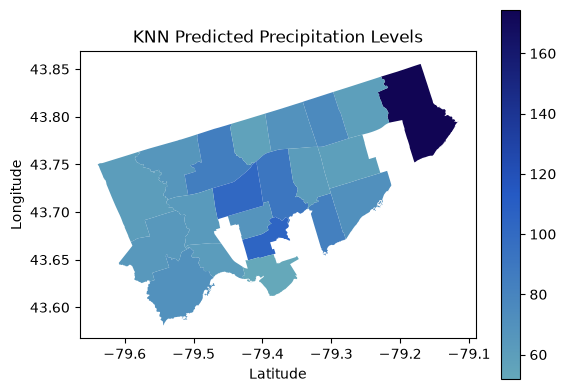

In [92]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

august_predicted_to = pd.merge(toronto, monthly_data_knn["August (Prediction)"], how="inner", left_on="AREA_NAME", right_index=True)
august_predicted_axis = august_predicted_to.plot("August (Prediction)", legend=True, cmap=rain_colormap)
plt.title("KNN Predicted Precipitation Levels")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

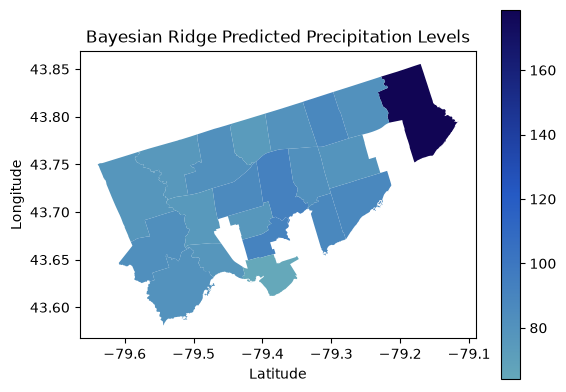

In [93]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

august_predicted_to = pd.merge(toronto, monthly_data_brr["August (Prediction)"], how="inner", left_on="AREA_NAME", right_index=True)
august_predicted_axis = august_predicted_to.plot("August (Prediction)", legend=True, cmap=rain_colormap)
plt.title("Bayesian Ridge Predicted Precipitation Levels")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

Text(24.722222222222214, 0.5, 'Longitude')

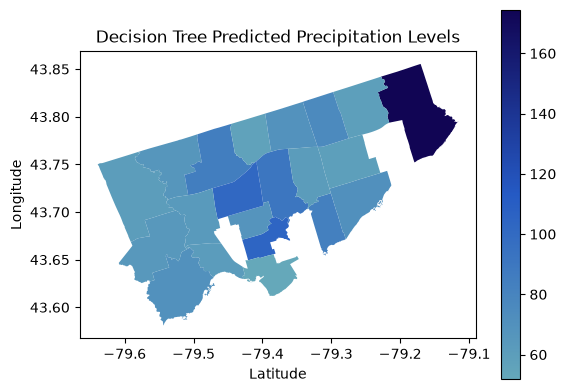

In [94]:
from matplotlib.colors import LinearSegmentedColormap
rain_colormap = LinearSegmentedColormap.from_list("custom_gradient", ["#65a8ba", "#255ac4", "#110554"])

august_predicted_to = pd.merge(toronto, monthly_data_dtr["August (Prediction)"], how="inner", left_on="AREA_NAME", right_index=True)
august_predicted_axis = august_predicted_to.plot("August (Prediction)", legend=True, cmap=rain_colormap)
plt.title("Decision Tree Predicted Precipitation Levels")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

## Comparisons of Different Regression Methods

### K Neighbors Regression

### Bayesian Ridge Regression

### Decision Tree Regression